# 03 — Feature Engineering
**Projeto:** Give Me Some Credit — Classificação de Risco de Crédito  
**Notebook:** `03_feature_engineering.ipynb`  
**Autor:** Eduardo EMF  
**Repositório:** [credit-risk-classifier](https://github.com/eduardoemf/credit-risk-classifier)

---

## 🎯 Objetivo

Este notebook transforma o dataset limpo em um conjunto de features mais informativo para a modelagem preditiva.

As decisões aqui são **orientadas pelos achados da EDA** (`02_analise_exploratoria.ipynb`):
- Variáveis com assimetria acentuada → transformações logarítmicas
- Variáveis de atraso altamente correlacionadas entre si → agregação
- Sinais combinados com maior poder preditivo do que isolados → features de interação
- Variáveis com domínio contínuo mas interpretação por faixas → binning

**Premissa:** cada nova feature precisa ser justificada analiticamente — feature engineering sem hipótese é ruído.

---

## 📋 Roadmap de Features

| # | Feature | Tipo | Origem | Hipótese |
|---|---|---|---|---|
| 1 | `log_monthly_income` | Transformação | `monthly_income` | Reduz assimetria; melhora separabilidade linear |
| 2 | `log_debt_ratio` | Transformação | `debt_ratio` | Reduz cauda longa; estabiliza escala |
| 3 | `total_late_occurrences` | Agregação | `late_30_59` + `late_60_89` + `late_90_plus` | Captura o efeito cumulativo de inadimplência |
| 4 | `has_any_late` | Binária | `total_late_occurrences` | Qualquer atraso é mais discriminativo do que a contagem |
| 5 | `max_late_severity` | Máximo | variáveis de atraso | Severidade máxima registrada |
| 6 | `util_x_late90` | Interação | `revolving_utilization` × `late_90_plus_days` | Alta utilização + atraso severo = risco amplificado |
| 7 | `income_per_dependent` | Razão | `monthly_income` / (`num_dependents` + 1) | Renda disponível por pessoa da família |
| 8 | `debt_to_income_stress` | Razão | `debt_ratio` × `revolving_utilization` | Estresse financeiro composto |
| 9 | `age_group` | Binning | `age` | Captura não-linearidade do risco por faixa etária |
| 10 | `credit_util_bin` | Binning | `revolving_utilization` | Faixas com diferentes perfis de risco |

---

## ⚙️ Configuração do Ambiente

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr, mannwhitneyu

# ── Opções de exibição ──────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# ── Tema visual padronizado ─────────────────────────────────────────
PALETTE_MAIN   = 'steelblue'
PALETTE_TARGET = {0: '#5b9bd5', 1: '#d9534f'}

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.figsize'   : (12, 5),
    'figure.dpi'       : 110,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

---

## 1. Carregamento dos Dados

In [2]:
df = pd.read_parquet('../data/processed/cs-training_cleaned.parquet')

print(f'Dimensões: {df.shape[0]:,} linhas × {df.shape[1]} colunas')
df.head()

Dimensões: 149,999 linhas × 11 colunas


,target_default_2y,revolving_utilization,age,debt_ratio,monthly_income,num_credit_lines,late_30_59_days,late_60_89_days,late_90_plus_days,num_real_estate_loans,num_dependents
0,1,0.7661,45,0.8030,9120.0000,13,2,0,0,6,2
1,0,0.9572,40,0.1219,2600.0000,4,0,0,0,0,1
2,0,0.6582,38,0.0851,3042.0000,2,1,0,1,0,0
3,0,0.2338,30,0.0360,3300.0000,5,0,0,0,0,0
4,0,0.9072,49,0.0249,23000.0000,7,1,0,0,1,0


> Dataset proveniente do pipeline de limpeza em `01_data_cleaning.ipynb`.  
> Trabalharemos em uma cópia (`df_fe`) para preservar o dataset original intacto durante o desenvolvimento.

In [3]:
# Cópia de trabalho — preserva o dataset original para comparações
df_fe = df.copy()

### 1.1 Função Auxiliar de Avaliação

Para manter o processo sistemático, utilizamos uma função que avalia cada nova feature de três ângulos:
1. **Correlação ponto-bisserial** — força da relação linear com o target binário
2. **Teste Mann-Whitney U** — diferença de distribuição entre as classes (não assume normalidade)
3. **Visualização** — distribuição por classe para validação visual

In [9]:
def evaluate_feature(df, feature, target='target_default_2y'):
    """
    Avalia o poder discriminativo de uma feature em relação ao target binário.

    Exibe:
    - KDE por classe + boxplot
    - Correlação ponto-bisserial
    - Teste Mann-Whitney U (p-valor)

    Args:
        df (pd.DataFrame): DataFrame com os dados.
        feature (str): Nome da feature a avaliar.
        target (str): Nome da coluna target binária.
    """
    grupo_0 = df.loc[df[target] == 0, feature].dropna()
    grupo_1 = df.loc[df[target] == 1, feature].dropna()

    # Correlação ponto-bisserial
    corr, p_corr = pointbiserialr(df[target].dropna(), df[feature].dropna())

    # Teste Mann-Whitney (não paramétrico — adequado para distribuições assimétricas)
    stat_mw, p_mw = mannwhitneyu(grupo_0, grupo_1, alternative='two-sided')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # KDE por classe
    for val, label, color in [(0, 'Adimplente (0)', PALETTE_TARGET[0]),
                               (1, 'Inadimplente (1)', PALETTE_TARGET[1])]:
        sns.kdeplot(df.loc[df[target] == val, feature].dropna(),
                    ax=axes[0], fill=True, alpha=0.45, label=label, color=color)
    axes[0].set_title(f'Distribuição por Classe — {feature}', fontsize=13)
    axes[0].set_xlabel(feature)
    axes[0].legend()

    # Boxplot por classe
    sns.boxplot(data=df, x=target, y=feature, palette=PALETTE_TARGET, hue=target, ax=axes[1])
    axes[1].set_title(f'Boxplot por Classe — {feature}', fontsize=13)
    axes[1].set_xlabel('Inadimplência (0 = Não | 1 = Sim)')
    axes[1].set_ylabel(feature)

    plt.suptitle(f'Avaliação da Feature: {feature}', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # Relatório estatístico
    sig_corr = '✅' if abs(corr) > 0.05 else '⚠️ '
    sig_mw   = '✅' if p_mw < 0.05 else '⚠️ '
    print(f'  {sig_corr} Correlação ponto-bisserial: {corr:+.4f}  (p = {p_corr:.2e})')
    print(f'  {sig_mw} Mann-Whitney U p-valor:     {p_mw:.2e}  ', end='')
    print('→ distribuições DIFERENTES entre classes' if p_mw < 0.05 else '→ diferença NÃO significativa')
    print(f'     Mediana adimplente:    {grupo_0.median():.4f}')
    print(f'     Mediana inadimplente:  {grupo_1.median():.4f}')

---

## 2. Transformações Logarítmicas

**Motivação (EDA):** `monthly_income` e `debt_ratio` apresentam assimetria positiva acentuada com cauda longa à direita.  
Modelos lineares e baseados em distância assumem distribuições aproximadamente simétricas — a transformação `log1p` (log(x + 1)) reduz o efeito dos outliers e pode melhorar a separabilidade entre classes.

> `log1p` é preferível a `log` puro porque lida corretamente com valores zero, que existem em `debt_ratio`.

### 2.1 `log_monthly_income`

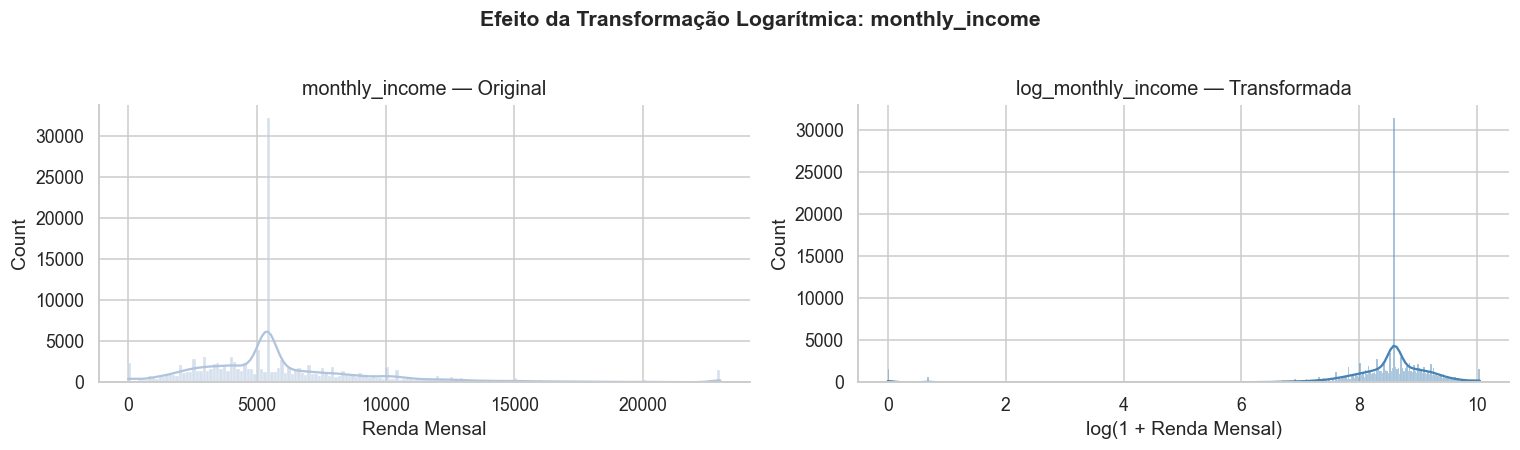

Assimetria (skewness) antes: 1.7452
Assimetria (skewness) após:  -5.0801  (redução de 6.8253)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Antes
sns.histplot(df_fe['monthly_income'], kde=True, color='lightsteelblue', ax=axes[0])
axes[0].set_title('monthly_income — Original', fontsize=13)
axes[0].set_xlabel('Renda Mensal')

# Depois
df_fe['log_monthly_income'] = np.log1p(df_fe['monthly_income'])
sns.histplot(df_fe['log_monthly_income'], kde=True, color=PALETTE_MAIN, ax=axes[1])
axes[1].set_title('log_monthly_income — Transformada', fontsize=13)
axes[1].set_xlabel('log(1 + Renda Mensal)')

plt.suptitle('Efeito da Transformação Logarítmica: monthly_income',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

skew_before = df_fe['monthly_income'].skew()
skew_after  = df_fe['log_monthly_income'].skew()
print(f'Assimetria (skewness) antes: {skew_before:.4f}')
print(f'Assimetria (skewness) após:  {skew_after:.4f}  (redução de {abs(skew_before - skew_after):.4f})')

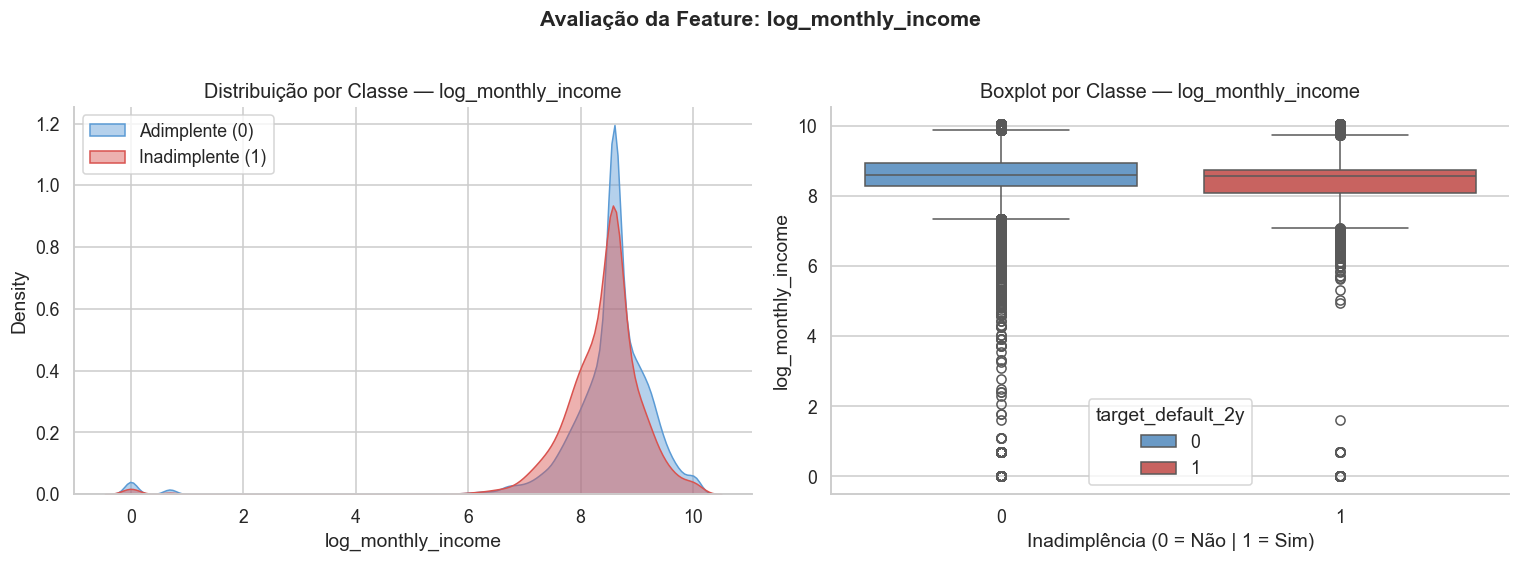

  ⚠️  Correlação ponto-bisserial: -0.0175  (p = 1.20e-11)
  ✅ Mann-Whitney U p-valor:     3.51e-126  → distribuições DIFERENTES entre classes
     Mediana adimplente:    8.5943
     Mediana inadimplente:  8.5643


In [10]:
evaluate_feature(df_fe, 'log_monthly_income')

> **Resultado:** A transformação logarítmica comprime a cauda direita, aproximando a distribuição da normalidade.  
> Compare a separabilidade visual entre classes antes e após: inadimplentes continuam com mediana inferior, mas a diferença fica mais legível sem o efeito distorcivo dos outliers extremos.

### 2.2 `log_debt_ratio`

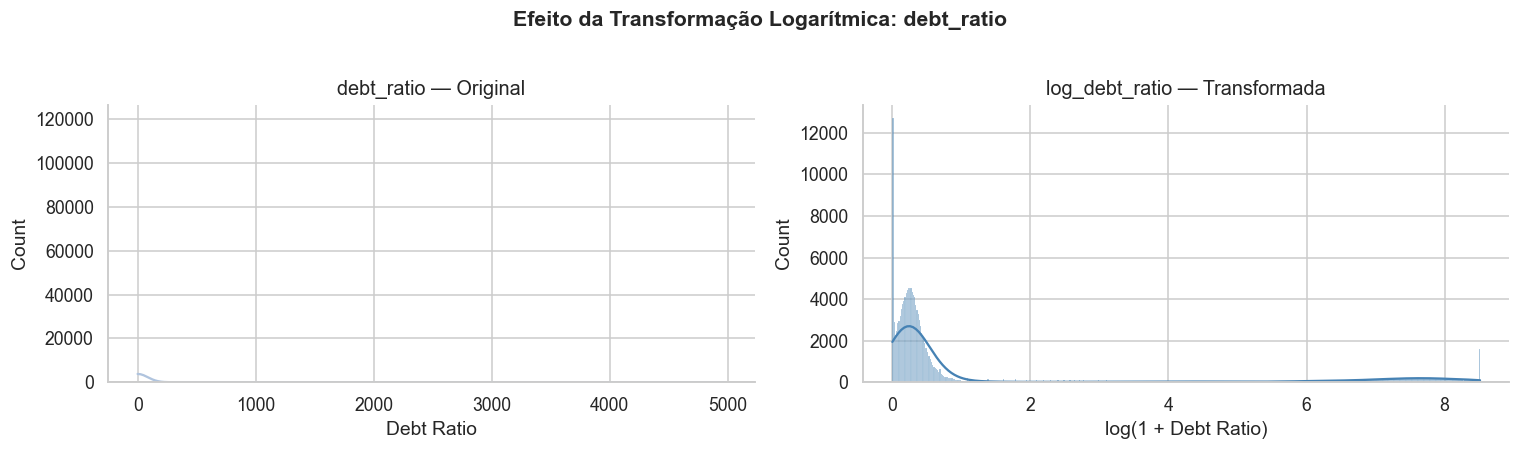

Assimetria (skewness) antes: 3.3511
Assimetria (skewness) após:  1.7406  (redução de 1.6106)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df_fe['debt_ratio'], kde=True, color='lightsteelblue', ax=axes[0])
axes[0].set_title('debt_ratio — Original', fontsize=13)
axes[0].set_xlabel('Debt Ratio')

df_fe['log_debt_ratio'] = np.log1p(df_fe['debt_ratio'])
sns.histplot(df_fe['log_debt_ratio'], kde=True, color=PALETTE_MAIN, ax=axes[1])
axes[1].set_title('log_debt_ratio — Transformada', fontsize=13)
axes[1].set_xlabel('log(1 + Debt Ratio)')

plt.suptitle('Efeito da Transformação Logarítmica: debt_ratio',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

skew_before = df_fe['debt_ratio'].skew()
skew_after  = df_fe['log_debt_ratio'].skew()
print(f'Assimetria (skewness) antes: {skew_before:.4f}')
print(f'Assimetria (skewness) após:  {skew_after:.4f}  (redução de {abs(skew_before - skew_after):.4f})')

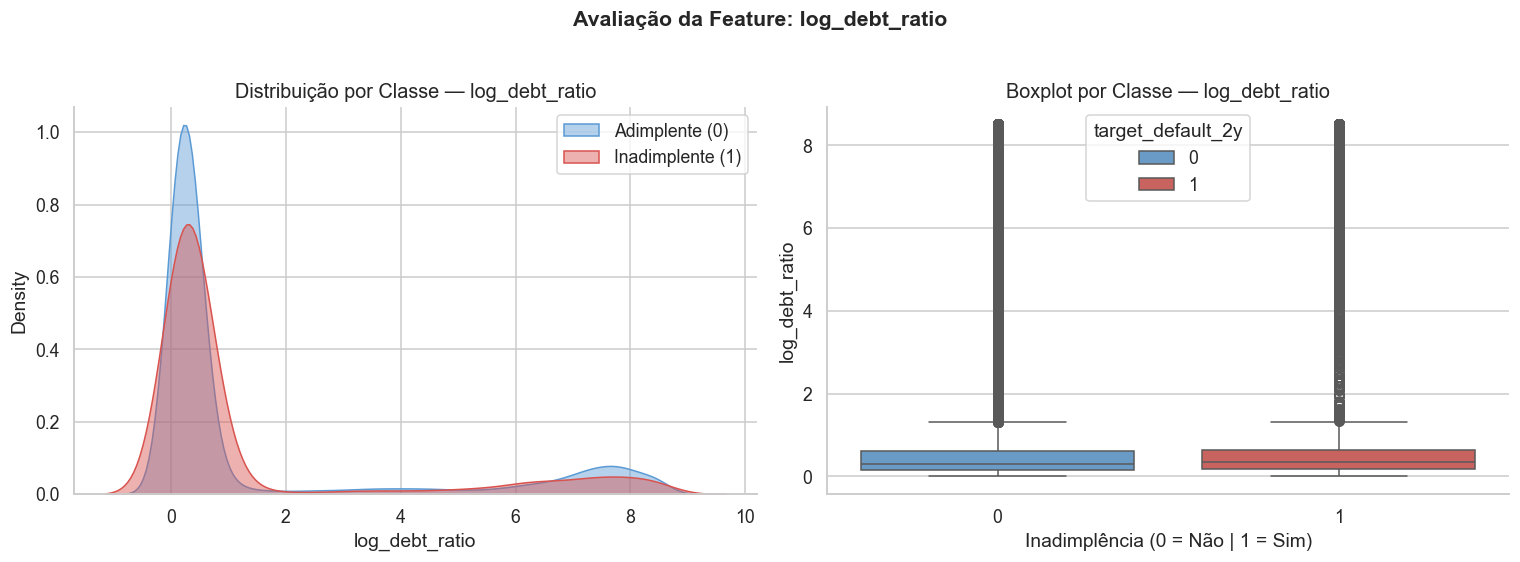

  ⚠️  Correlação ponto-bisserial: -0.0174  (p = 1.77e-11)
  ✅ Mann-Whitney U p-valor:     1.52e-15  → distribuições DIFERENTES entre classes
     Mediana adimplente:    0.3094
     Mediana inadimplente:  0.3564


In [12]:
evaluate_feature(df_fe, 'log_debt_ratio')

> **Nota:** `debt_ratio` tem sinal fraco na correlação linear com o target (conforme EDA), mas a transformação pode revelar padrões não-lineares que a correlação de Pearson não captura.  
> Se o sinal permanecer fraco após a transformação, esta feature pode não contribuir significativamente para modelos lineares — mas ainda é válida para modelos baseados em árvores, onde a transformação não é necessária.

---

## 3. Features de Histórico de Atraso

**Motivação (EDA):** As três variáveis de atraso são altamente correlacionadas entre si e formam um cluster claro no dendrograma. Além disso, a análise de interação mostrou que a combinação de atrasos em múltiplas faixas **amplifica o risco** além do efeito individual de cada uma.

O objetivo aqui é criar representações que capturem o **comportamento cumulativo de inadimplência** sem introduzir multicolinearidade adicional.

### 3.1 `total_late_occurrences` — Contagem Agregada

In [13]:
# Soma de todas as ocorrências de atraso em qualquer faixa
df_fe['total_late_occurrences'] = (
    df_fe['late_30_59_days'] +
    df_fe['late_60_89_days'] +
    df_fe['late_90_plus_days']
)

print('Distribuição de total_late_occurrences:')
print(df_fe['total_late_occurrences'].value_counts().sort_index().head(10))
print(f'\nMáximo: {df_fe["total_late_occurrences"].max()}')
print(f'% de clientes com ao menos 1 atraso: {(df_fe["total_late_occurrences"] > 0).mean()*100:.2f}%')

Distribuição de total_late_occurrences:
total_late_occurrences
0    119637
1     17242
2      5942
3      2896
4      1697
5      1065
6       610
7       343
8       168
9        77
Name: count, dtype: int64

Máximo: 12
% de clientes com ao menos 1 atraso: 20.24%


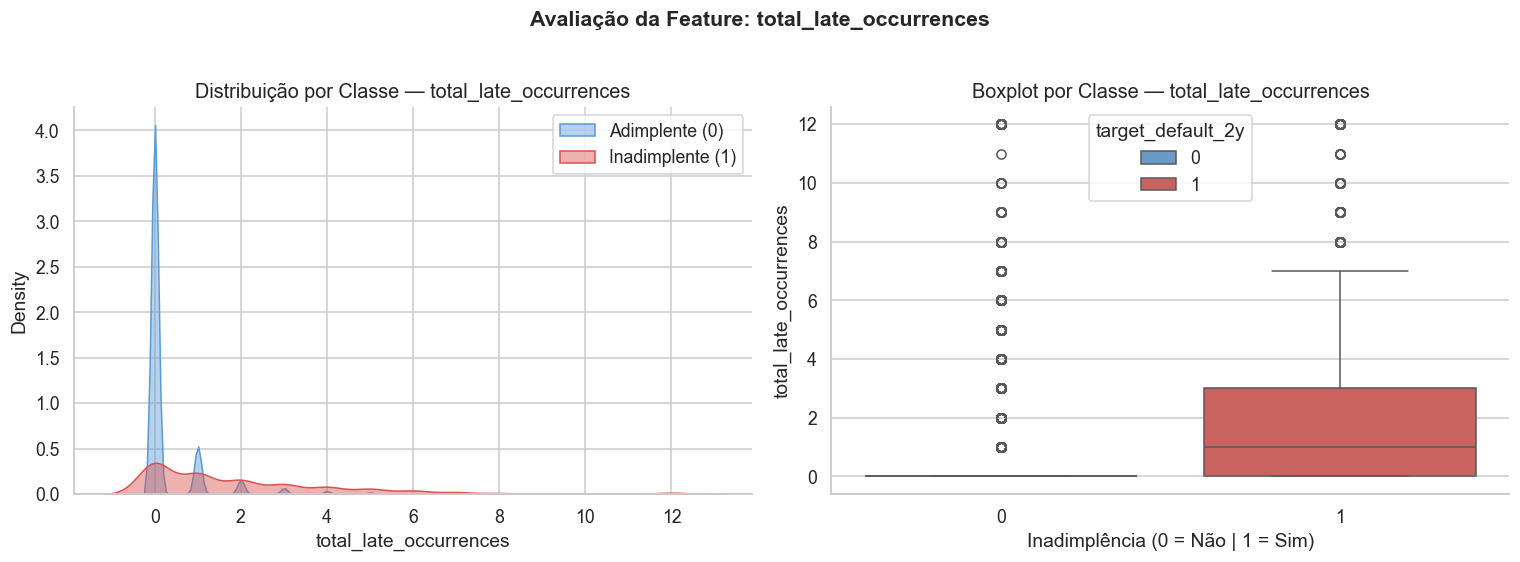

  ✅ Correlação ponto-bisserial: +0.3926  (p = 0.00e+00)
  ✅ Mann-Whitney U p-valor:     0.00e+00  → distribuições DIFERENTES entre classes
     Mediana adimplente:    0.0000
     Mediana inadimplente:  1.0000


In [14]:
evaluate_feature(df_fe, 'total_late_occurrences')

> **Hipótese validada:** A contagem agregada de atrasos é um sinal mais forte do que qualquer variável individual — captura clientes que acumularam inadimplências em múltiplas faixas.

### 3.2 `has_any_late` — Flag Binária de Inadimplência

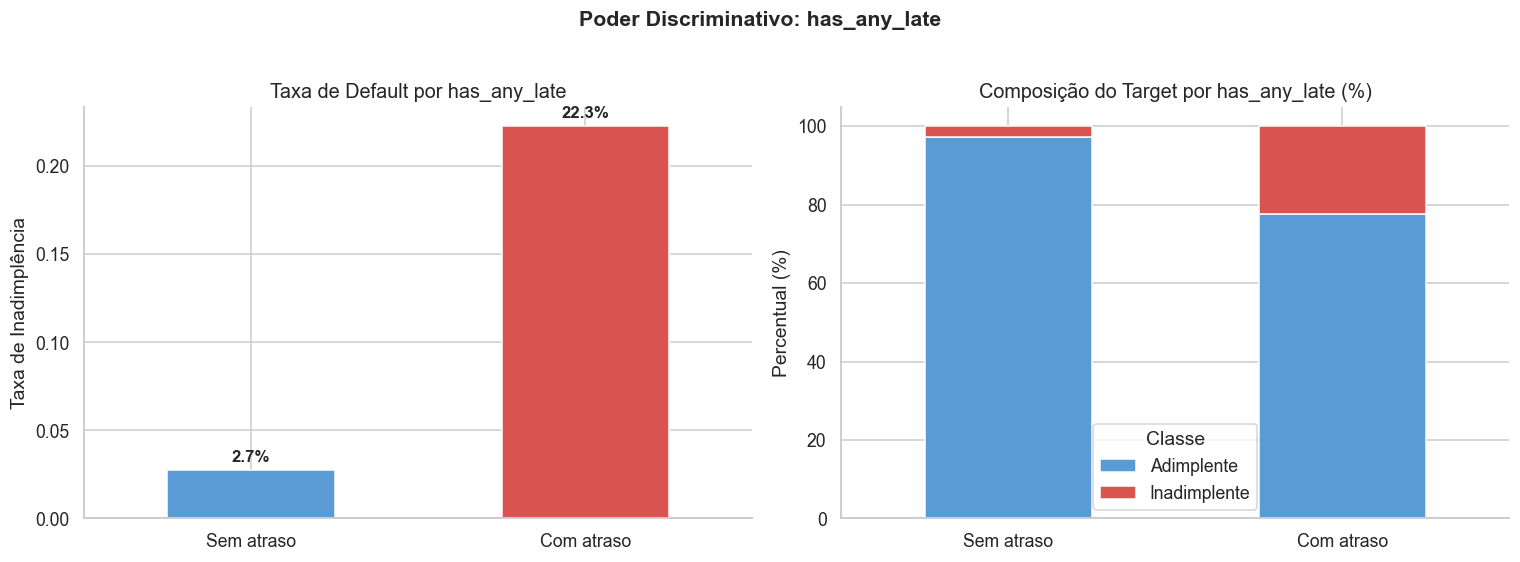

Taxa de default por grupo:
has_any_late
Sem atraso   0.0273
Com atraso   0.2227


In [15]:
# Flag: cliente já teve ao menos um atraso em qualquer faixa?
df_fe['has_any_late'] = (df_fe['total_late_occurrences'] > 0).astype(int)

# Taxa de inadimplência por grupo
taxa = df_fe.groupby('has_any_late')['target_default_2y'].mean().rename({0: 'Sem atraso', 1: 'Com atraso'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taxa de default por grupo
taxa.plot(kind='bar', color=[PALETTE_TARGET[0], PALETTE_TARGET[1]],
          edgecolor='white', ax=axes[0])
axes[0].set_title('Taxa de Default por has_any_late', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('Taxa de Inadimplência')
axes[0].set_xticklabels(['Sem atraso', 'Com atraso'], rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{bar.get_height():.1%}', ha='center', fontsize=11, fontweight='bold')

# Composição do target dentro de cada grupo
cross = pd.crosstab(df_fe['has_any_late'], df_fe['target_default_2y'], normalize='index') * 100
cross.plot(kind='bar', stacked=True,
           color=[PALETTE_TARGET[0], PALETTE_TARGET[1]],
           edgecolor='white', ax=axes[1])
axes[1].set_title('Composição do Target por has_any_late (%)', fontsize=13)
axes[1].set_xlabel('')
axes[1].set_ylabel('Percentual (%)')
axes[1].set_xticklabels(['Sem atraso', 'Com atraso'], rotation=0)
axes[1].legend(['Adimplente', 'Inadimplente'], title='Classe')

plt.suptitle('Poder Discriminativo: has_any_late', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Taxa de default por grupo:')
print(taxa.to_string())

> **Insight:** A simples presença de qualquer atraso — independentemente da faixa — já divide a base em dois grupos com perfis de risco radicalmente diferentes.  
> Esta é possivelmente a feature binária mais discriminativa do dataset.

### 3.3 `max_late_severity` — Severidade Máxima de Atraso

In [16]:
# Maior faixa de atraso já registrada: captura a severidade máxima do comportamento
# Ponderamos pela severidade: atraso 90+ vale mais do que 30-59
df_fe['max_late_severity'] = df_fe[['late_30_59_days',
                                     'late_60_89_days',
                                     'late_90_plus_days']].max(axis=1)

print('Distribuição de max_late_severity:')
print(df_fe['max_late_severity'].value_counts().sort_index().head(10))

Distribuição de max_late_severity:
max_late_severity
0    119637
1     19790
2      5886
3      2531
4      1305
5       850
Name: count, dtype: int64


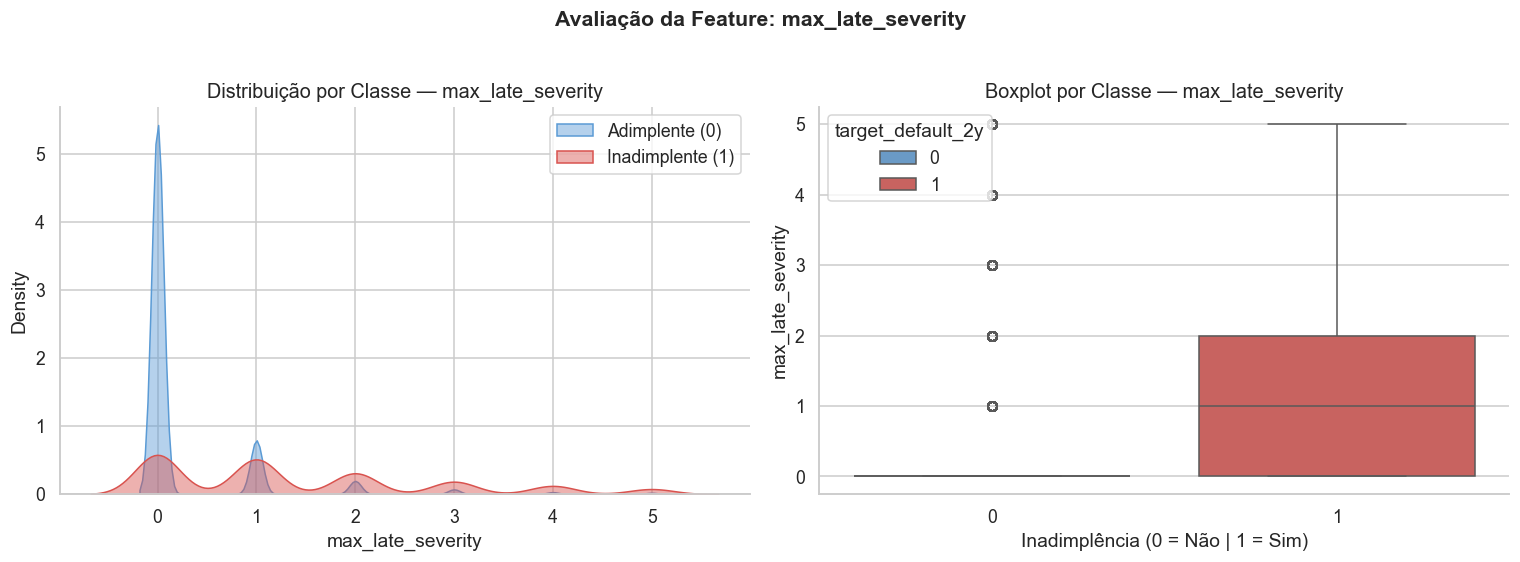

  ✅ Correlação ponto-bisserial: +0.3756  (p = 0.00e+00)
  ✅ Mann-Whitney U p-valor:     0.00e+00  → distribuições DIFERENTES entre classes
     Mediana adimplente:    0.0000
     Mediana inadimplente:  1.0000


In [17]:
evaluate_feature(df_fe, 'max_late_severity')

> **Lógica:** Um cliente com 5 ocorrências de atraso leve (30–59 dias) pode ter perfil diferente de um com 2 ocorrências de atraso severo (90+ dias). Esta feature captura o **pico de severidade** — complementar a `total_late_occurrences`.

---

## 4. Features de Interação

**Motivação (EDA):** A análise de interações mostrou que `revolving_utilization` e as variáveis de atraso se potencializam — clientes com alta utilização de crédito **e** histórico de atraso severo concentram as maiores taxas de default.

### 4.1 `util_x_late90` — Utilização × Atraso Severo

In [18]:
# Produto direto: quanto maior a utilização E mais atrasos severos, maior o sinal
df_fe['util_x_late90'] = df_fe['revolving_utilization'] * df_fe['late_90_plus_days']

print(f'% de clientes com util_x_late90 = 0: {(df_fe["util_x_late90"] == 0).mean()*100:.2f}%')
print(f'Máximo: {df_fe["util_x_late90"].max():.4f}')

% de clientes com util_x_late90 = 0: 94.67%
Máximo: 4.0000


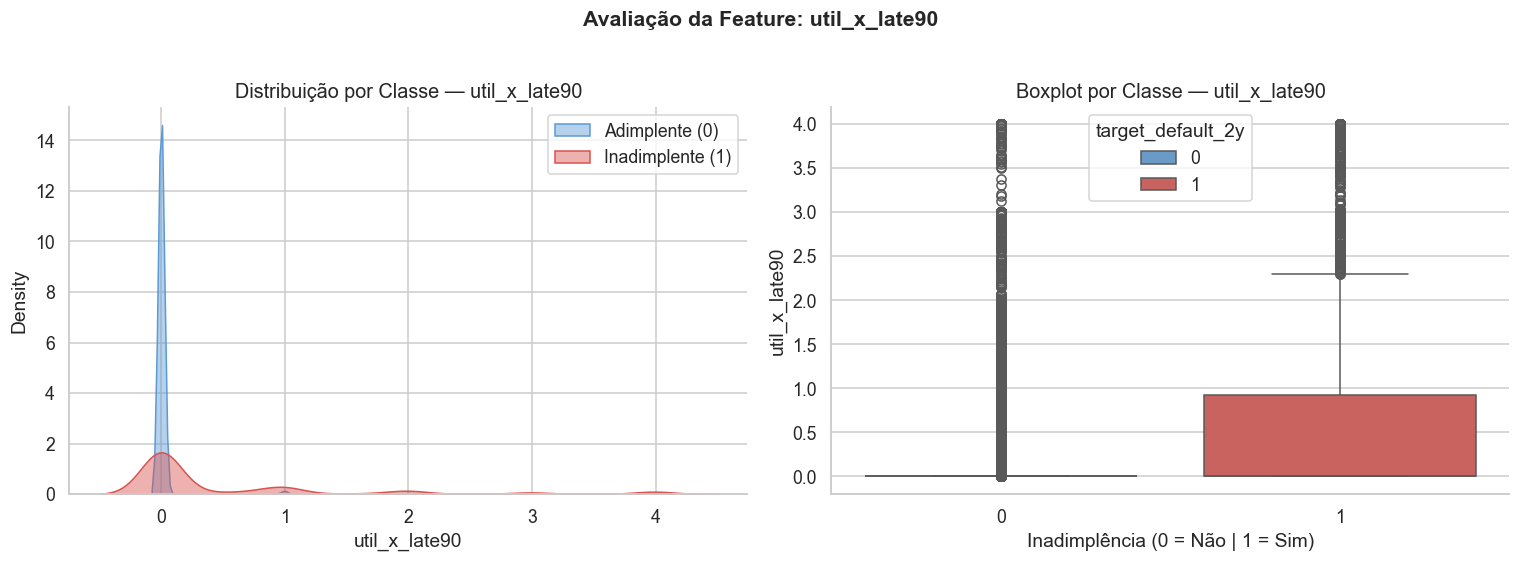

  ✅ Correlação ponto-bisserial: +0.3281  (p = 0.00e+00)
  ✅ Mann-Whitney U p-valor:     0.00e+00  → distribuições DIFERENTES entre classes
     Mediana adimplente:    0.0000
     Mediana inadimplente:  0.0000


In [19]:
evaluate_feature(df_fe, 'util_x_late90')

> **Hipótese:** A combinação de alta utilização de crédito com atrasos severos representa o perfil de maior risco — o produto das duas variáveis captura esse efeito conjunto que as variáveis originais não expressam individualmente.

### 4.2 `debt_to_income_stress` — Estresse Financeiro Composto

In [20]:
# Combina comprometimento de renda (debt_ratio) com pressão sobre limite de crédito (revolving_utilization)
# Ambas medem formas diferentes de estresse financeiro — o produto captura a sobreposição
df_fe['debt_to_income_stress'] = df_fe['debt_ratio'] * df_fe['revolving_utilization']

print(f'Correlação com target: {df_fe["debt_to_income_stress"].corr(df_fe["target_default_2y"]):.4f}')

Correlação com target: 0.0451


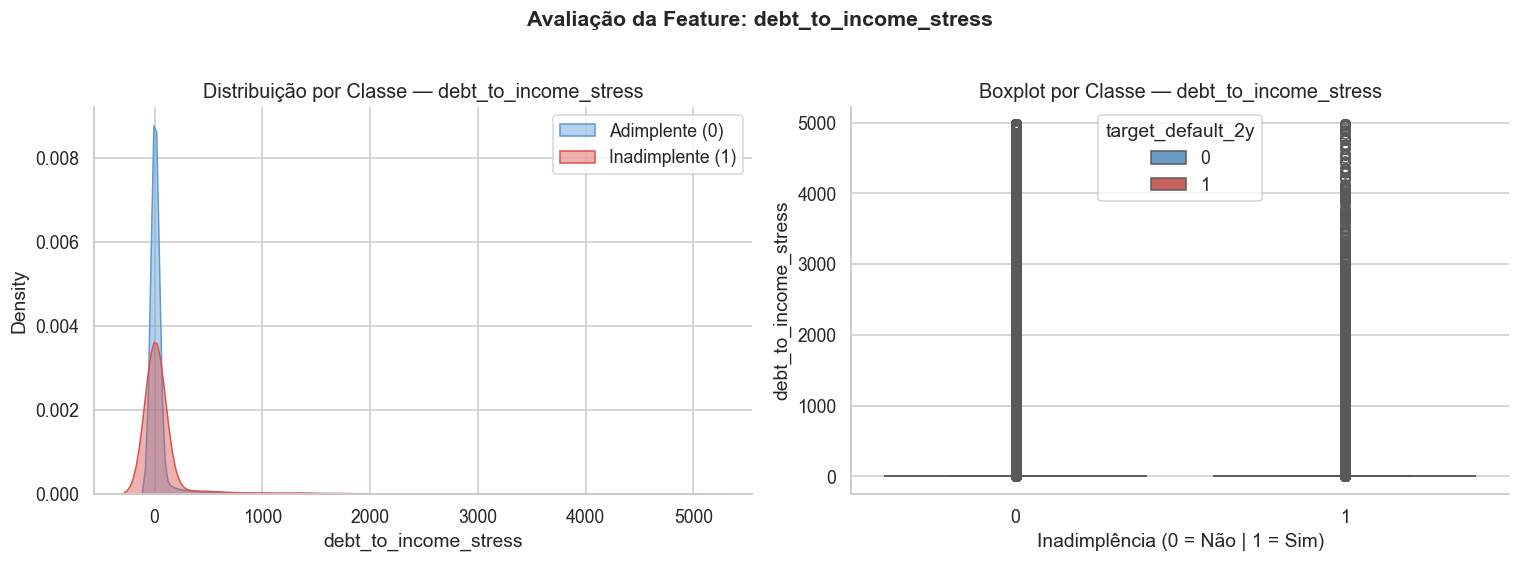

  ⚠️  Correlação ponto-bisserial: +0.0451  (p = 2.10e-68)
  ✅ Mann-Whitney U p-valor:     0.00e+00  → distribuições DIFERENTES entre classes
     Mediana adimplente:    0.0676
     Mediana inadimplente:  0.2557


In [21]:
evaluate_feature(df_fe, 'debt_to_income_stress')

> **Lógica:** `debt_ratio` sozinho tem sinal fraco (conforme EDA), mas quando combinado com `revolving_utilization` — que é forte — o produto pode revelar perfis de estresse financeiro mais bem definidos.

---

## 5. Features de Razão

Features construídas a partir de razões entre variáveis capturam **capacidade relativa** — mais informativa do que valores absolutos em contextos financeiros.

### 5.1 `income_per_dependent` — Renda por Dependente

In [22]:
# Renda disponível por pessoa da família (incluindo o próprio cliente)
# +1 evita divisão por zero para clientes sem dependentes
df_fe['income_per_dependent'] = df_fe['monthly_income'] / (df_fe['num_dependents'] + 1)

print(f'Mínimo: {df_fe["income_per_dependent"].min():,.2f}')
print(f'Mediana: {df_fe["income_per_dependent"].median():,.2f}')
print(f'Máximo: {df_fe["income_per_dependent"].max():,.2f}')

Mínimo: 0.00
Mediana: 4,000.00
Máximo: 23,000.00


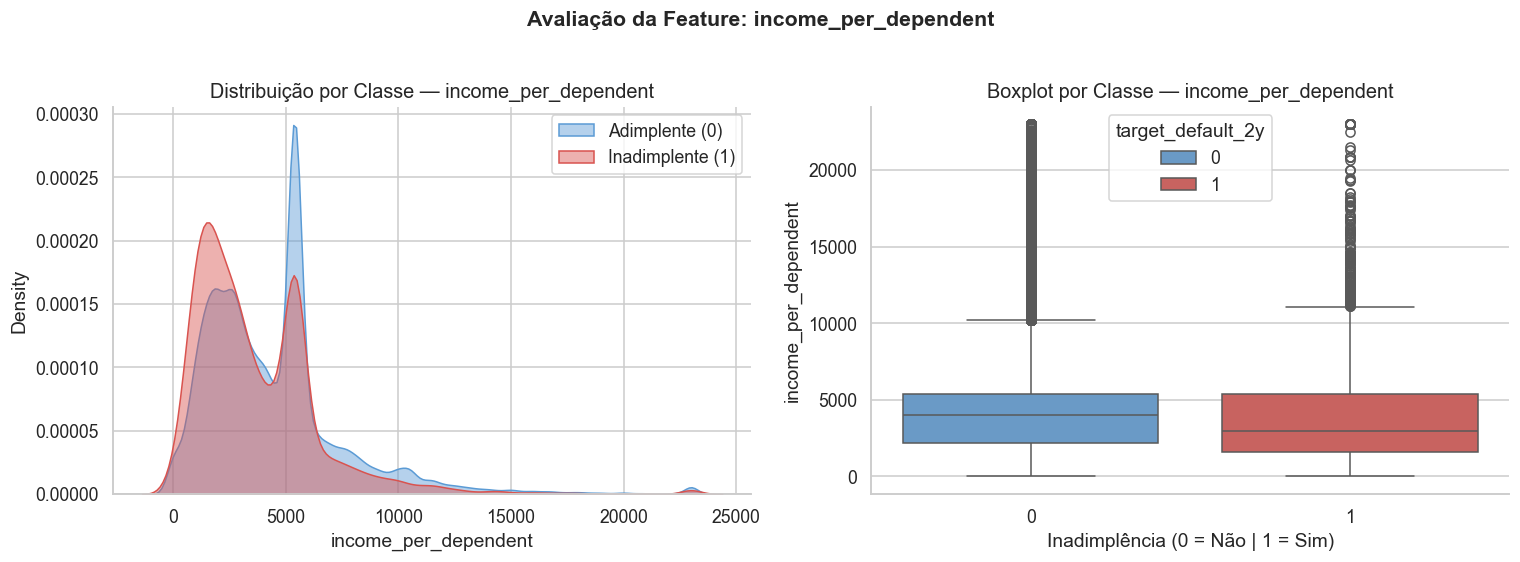

  ✅ Correlação ponto-bisserial: -0.0621  (p = 3.96e-128)
  ✅ Mann-Whitney U p-valor:     6.45e-189  → distribuições DIFERENTES entre classes
     Mediana adimplente:    4044.0000
     Mediana inadimplente:  2966.8333


In [23]:
evaluate_feature(df_fe, 'income_per_dependent')

> **Hipótese:** A renda absoluta pode não refletir a real capacidade de pagamento — dois clientes com a mesma renda têm folga orçamentária muito diferente se um sustenta 4 dependentes e o outro nenhum.

---

## 6. Binning — Discretização de Variáveis Contínuas

O binning transforma variáveis contínuas em categorias ordinais, permitindo ao modelo capturar **não-linearidades** que regressões simples podem perder.

### 6.1 `age_group` — Faixas Etárias

In [25]:
# Faixas etárias com significado financeiro
bins_age   = [0, 30, 40, 50, 65, 120]
labels_age = ['< 30', '30–39', '40–49', '50–64', '65+']

df_fe['age_group'] = pd.cut(df_fe['age'], bins=bins_age, labels=labels_age, right=False)

print('Distribuição de age_group:')
print(df_fe['age_group'].value_counts().sort_index())

Distribuição de age_group:
age_group
< 30      8820
30–39    23183
40–49    34377
50–64    52426
65+      31193
Name: count, dtype: int64


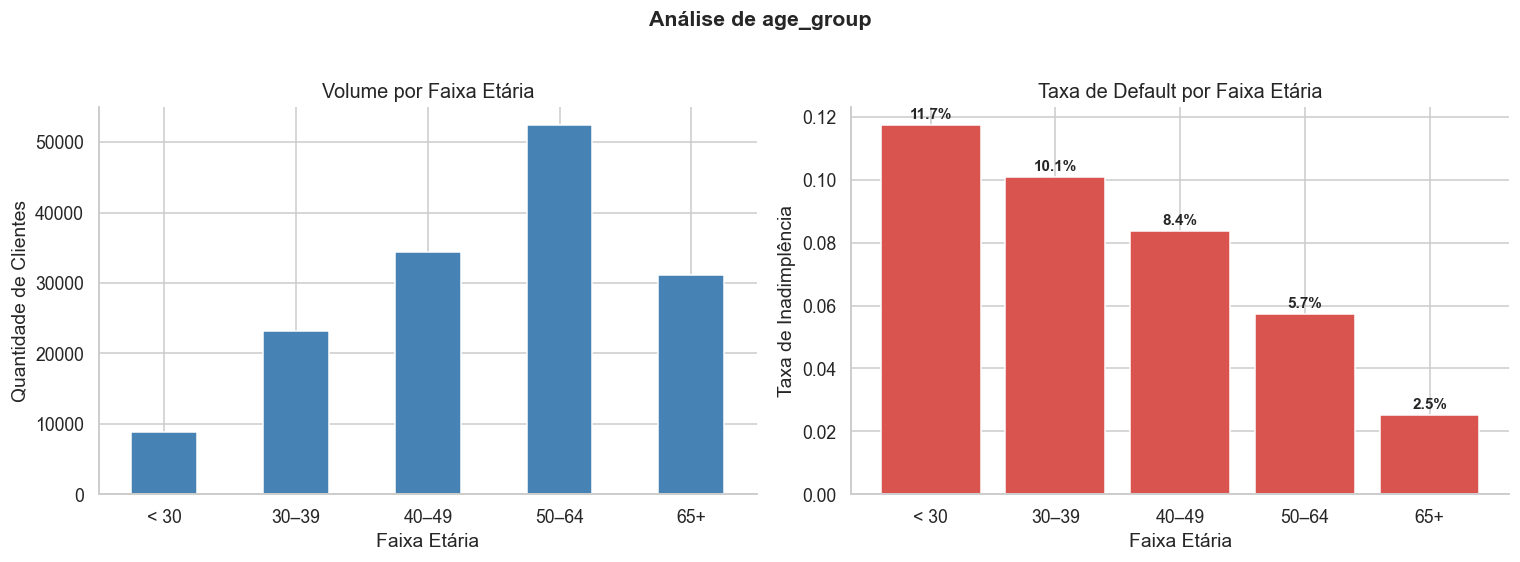

In [26]:
# Taxa de default por faixa etária
taxa_age = df_fe.groupby('age_group', observed=True)['target_default_2y'].mean().reset_index()
taxa_age.columns = ['age_group', 'taxa_default']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Volume por faixa
df_fe['age_group'].value_counts().sort_index().plot(
    kind='bar', color=PALETTE_MAIN, edgecolor='white', ax=axes[0])
axes[0].set_title('Volume por Faixa Etária', fontsize=13)
axes[0].set_xlabel('Faixa Etária')
axes[0].set_ylabel('Quantidade de Clientes')
axes[0].tick_params(axis='x', rotation=0)

# Taxa de default por faixa
bars = axes[1].bar(taxa_age['age_group'].astype(str),
                   taxa_age['taxa_default'],
                   color=PALETTE_TARGET[1], edgecolor='white')
axes[1].set_title('Taxa de Default por Faixa Etária', fontsize=13)
axes[1].set_xlabel('Faixa Etária')
axes[1].set_ylabel('Taxa de Inadimplência')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{bar.get_height():.1%}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Análise de age_group', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **Insight esperado:** Clientes mais jovens (< 30) tipicamente têm menor histórico de crédito e maior volatilidade financeira — a faixa etária pode capturar não-linearidades que `age` como variável contínua não expressaria tão bem em alguns modelos.

### 6.2 `credit_util_bin` — Faixas de Utilização do Crédito

In [27]:
# Faixas com interpretação de negócio clara
bins_util   = [0.0, 0.30, 0.60, 0.90, 1.01]
labels_util = ['Baixa (0–30%)', 'Moderada (30–60%)', 'Alta (60–90%)', 'Crítica (90–100%)']

df_fe['credit_util_bin'] = pd.cut(df_fe['revolving_utilization'],
                                   bins=bins_util, labels=labels_util,
                                   right=False, include_lowest=True)

print('Distribuição de credit_util_bin:')
print(df_fe['credit_util_bin'].value_counts().sort_index())

Distribuição de credit_util_bin:
credit_util_bin
Baixa (0–30%)        92882
Moderada (30–60%)    21887
Alta (60–90%)        15161
Crítica (90–100%)    20069
Name: count, dtype: int64


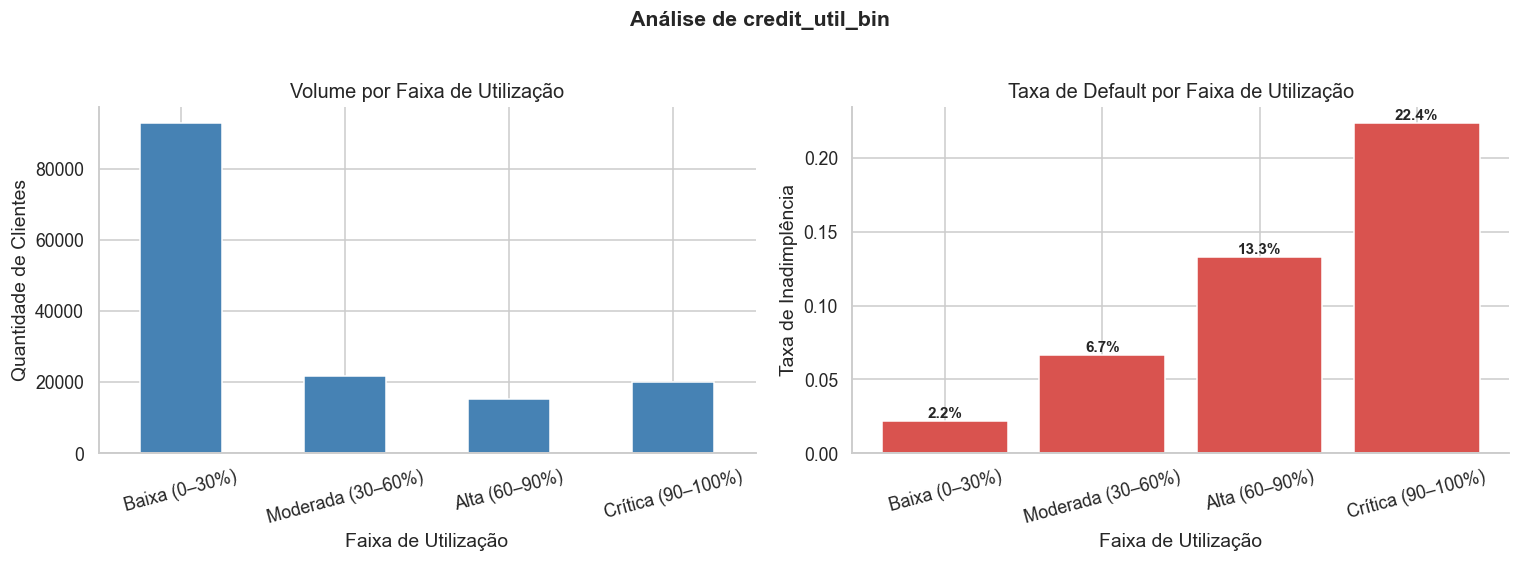

In [28]:
# Taxa de default por faixa de utilização
taxa_util = df_fe.groupby('credit_util_bin', observed=True)['target_default_2y'].mean().reset_index()
taxa_util.columns = ['credit_util_bin', 'taxa_default']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_fe['credit_util_bin'].value_counts().sort_index().plot(
    kind='bar', color=PALETTE_MAIN, edgecolor='white', ax=axes[0])
axes[0].set_title('Volume por Faixa de Utilização', fontsize=13)
axes[0].set_xlabel('Faixa de Utilização')
axes[0].set_ylabel('Quantidade de Clientes')
axes[0].tick_params(axis='x', rotation=15)

bars = axes[1].bar(taxa_util['credit_util_bin'].astype(str),
                   taxa_util['taxa_default'],
                   color=PALETTE_TARGET[1], edgecolor='white')
axes[1].set_title('Taxa de Default por Faixa de Utilização', fontsize=13)
axes[1].set_xlabel('Faixa de Utilização')
axes[1].set_ylabel('Taxa de Inadimplência')
axes[1].tick_params(axis='x', rotation=15)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{bar.get_height():.1%}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Análise de credit_util_bin', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **Insight esperado:** A taxa de default deve escalar claramente com a faixa de utilização, confirmando a não-linearidade que a EDA sinalizou — a faixa "Crítica" (90–100%) deve concentrar uma proporção desproporcionalmente alta de inadimplentes.

---

## 7. Visão Consolidada das Features

### 7.1 Ranking de Correlação — Originais vs. Novas Features

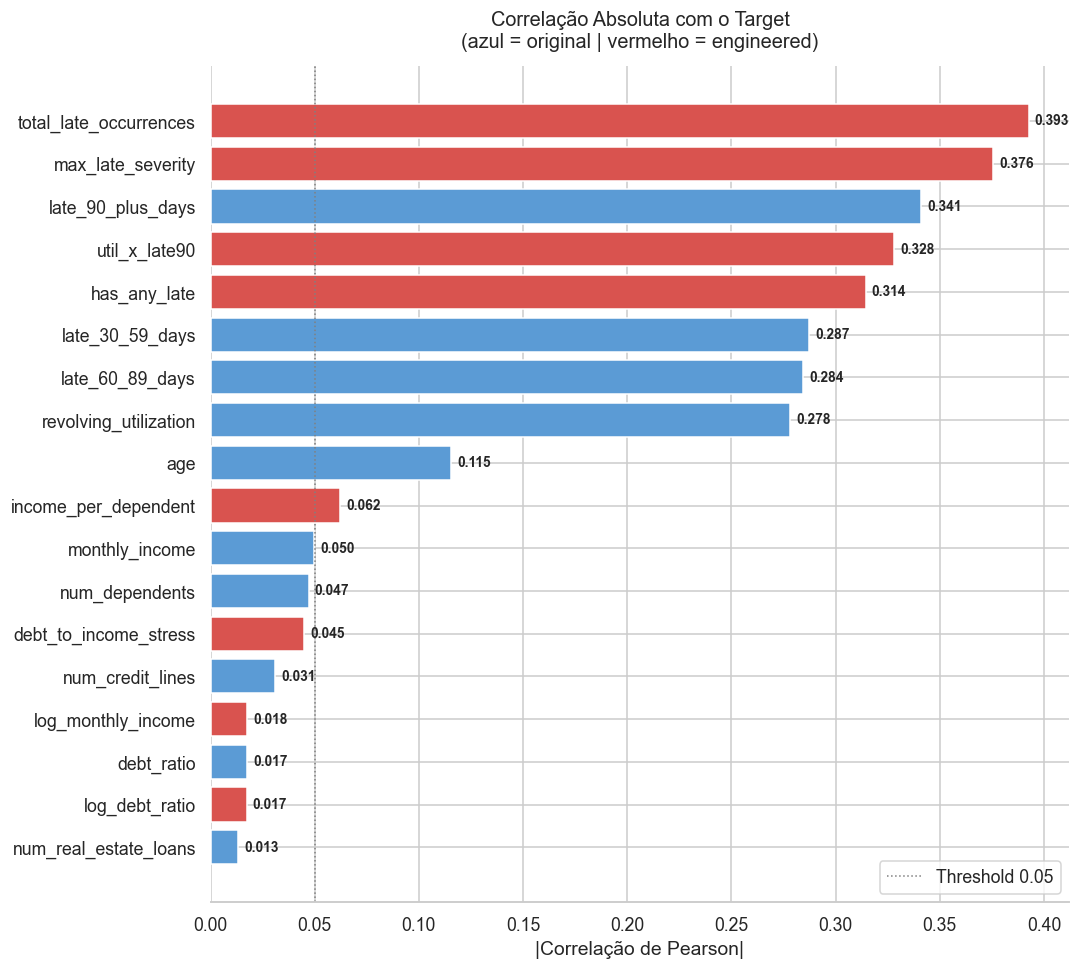

In [29]:
# Seleciona apenas colunas numéricas para correlação
numeric_cols = df_fe.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'target_default_2y']

corr_all = df_fe[numeric_cols + ['target_default_2y']] \
               .corr(numeric_only=True)['target_default_2y'] \
               .drop('target_default_2y') \
               .abs() \
               .sort_values(ascending=True)

# Colorir por origem (original vs. engineered)
original_features = [
    'revolving_utilization', 'age', 'debt_ratio', 'monthly_income',
    'num_credit_lines', 'late_30_59_days', 'late_60_89_days',
    'late_90_plus_days', 'num_real_estate_loans', 'num_dependents'
]
colors = [PALETTE_TARGET[0] if c in original_features else PALETTE_TARGET[1]
          for c in corr_all.index]

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(corr_all.index, corr_all.values, color=colors, edgecolor='white')
ax.bar_label(bars, padding=4, fmt='%.3f', fontsize=9, fontweight='bold')
ax.set_title('Correlação Absoluta com o Target\n(azul = original | vermelho = engineered)',
             fontsize=13, pad=12)
ax.set_xlabel('|Correlação de Pearson|')
ax.axvline(0.05, color='gray', linestyle=':', linewidth=1, label='Threshold 0.05')
ax.legend()
sns.despine(left=True)
plt.tight_layout()
plt.show()

### 7.2 Matriz de Correlação — Novas Features entre Si

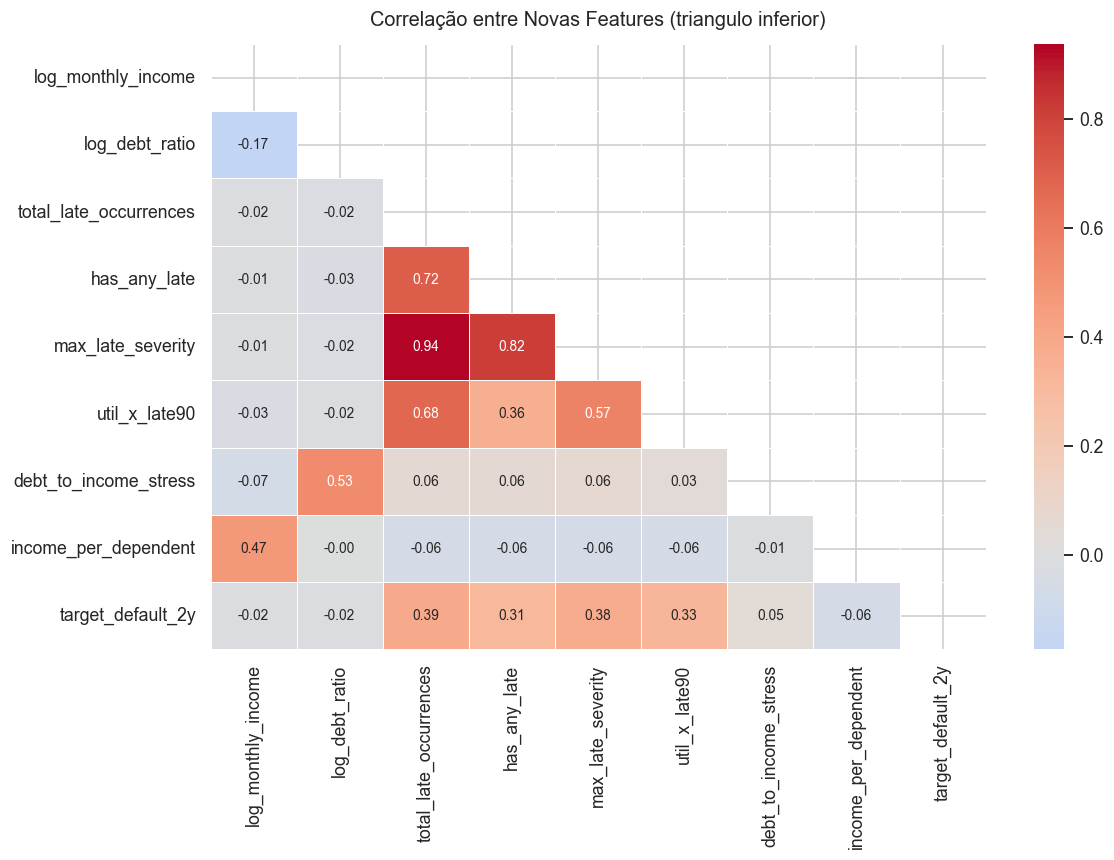

In [30]:
# Verificação de multicolinearidade entre as novas features
new_features = [
    'log_monthly_income', 'log_debt_ratio',
    'total_late_occurrences', 'has_any_late', 'max_late_severity',
    'util_x_late90', 'debt_to_income_stress', 'income_per_dependent',
    'target_default_2y'
]

corr_new = df_fe[new_features].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_new, dtype=bool))
sns.heatmap(corr_new, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, ax=ax, annot_kws={'size': 9})
ax.set_title('Correlação entre Novas Features (triangulo inferior)',
             fontsize=13, pad=12)
plt.tight_layout()
plt.show()

> **O que observar:**
> - `total_late_occurrences`, `has_any_late` e `max_late_severity` são derivadas das mesmas variáveis de atraso — alta correlação entre si é esperada e não é problema para modelos baseados em árvores
> - Para modelos lineares (Logistic Regression), escolher apenas uma das três pode ser mais adequado
> - `util_x_late90` deve ser moderadamente correlacionada com `revolving_utilization` — verificar se agrega sinal adicional

### 7.3 Snapshot do Dataset Final

In [31]:
print(f'Dimensões finais: {df_fe.shape[0]:,} linhas × {df_fe.shape[1]} colunas')
print(f'\nColunas originais: {len(original_features)}')
print(f'Colunas novas:     {df_fe.shape[1] - len(original_features) - 1}  (excluindo target)')
print()
print('Todas as colunas:')
for col in df_fe.columns:
    marker = '🆕' if col not in original_features + ['target_default_2y'] else '  '
    print(f'  {marker} {col}  [{df_fe[col].dtype}]')

Dimensões finais: 149,999 linhas × 21 colunas

Colunas originais: 10
Colunas novas:     10  (excluindo target)

Todas as colunas:
     target_default_2y  [int64]
     revolving_utilization  [float64]
     age  [int64]
     debt_ratio  [float64]
     monthly_income  [float64]
     num_credit_lines  [int64]
     late_30_59_days  [int64]
     late_60_89_days  [int64]
     late_90_plus_days  [int64]
     num_real_estate_loans  [int64]
     num_dependents  [int64]
  🆕 log_monthly_income  [float64]
  🆕 log_debt_ratio  [float64]
  🆕 total_late_occurrences  [int64]
  🆕 has_any_late  [int64]
  🆕 max_late_severity  [int64]
  🆕 util_x_late90  [float64]
  🆕 debt_to_income_stress  [float64]
  🆕 income_per_dependent  [float64]
  🆕 age_group  [category]
  🆕 credit_util_bin  [category]


In [32]:
df_fe.describe().T

,count,mean,std,min,25%,50%,75%,max
target_default_2y,149999.0000,0.0668,0.2497,0.0000,0.0000,0.0000,0.0000,1.0000
revolving_utilization,149999.0000,0.3192,0.3495,0.0000,0.0299,0.1542,0.5590,1.0000
age,149999.0000,52.2956,14.7713,21.0000,41.0000,52.0000,63.0000,109.0000
debt_ratio,149999.0000,316.5514,906.9669,0.0000,0.1751,0.3665,0.8683,4979.0800
monthly_income,149999.0000,6142.4463,3835.6914,0.0000,3903.0000,5400.0000,7400.0000,23000.0000
num_credit_lines,149999.0000,8.4274,5.0259,0.0000,5.0000,8.0000,11.0000,27.0000
late_30_59_days,149999.0000,0.2515,0.7020,0.0000,0.0000,0.0000,0.0000,5.0000
late_60_89_days,149999.0000,0.0682,0.3296,0.0000,0.0000,0.0000,0.0000,3.0000
late_90_plus_days,149999.0000,0.0923,0.4484,0.0000,0.0000,0.0000,0.0000,4.0000
num_real_estate_loans,149999.0000,1.0078,1.0433,0.0000,0.0000,1.0000,2.0000,6.0000


---

## 8. Exportação

Salvamos duas versões:
1. **`cs-training_features.parquet`** — dataset completo com todas as features (originais + engineered), para inspeção e iteração
2. O subset de features selecionadas para modelagem será definido em `04_balanceamento.ipynb` após análise de importância

In [33]:
output_path = '../data/processed/cs-training_features.parquet'
df_fe.to_parquet(output_path, index=False)

print(f'✅ Dataset exportado para: {output_path}')
print(f'   Linhas: {df_fe.shape[0]:,}  |  Colunas: {df_fe.shape[1]}')

✅ Dataset exportado para: ../data/processed/cs-training_features.parquet
   Linhas: 149,999  |  Colunas: 21


---

## 9. Conclusões e Direcionamentos

### 📊 Sumário das Features Criadas

| Feature | Tipo | Hipótese | Validar na Modelagem |
|---|---|---|---|
| `log_monthly_income` | Log transform | Reduz assimetria, melhora separabilidade | Comparar AUC com/sem |
| `log_debt_ratio` | Log transform | Idem; sinal original fraco | Testar importance no tree model |
| `total_late_occurrences` | Agregação | Efeito cumulativo de inadimplência | Esperado alto SHAP value |
| `has_any_late` | Flag binária | Qualquer atraso = mudança de perfil | Verificar lift no threshold |
| `max_late_severity` | Máximo | Severidade pico do comportamento | Avaliar vs. `total_late_occurrences` |
| `util_x_late90` | Interação | Alta utilização + atraso severo = risco máximo | Correlação parcial controlando por variáveis base |
| `debt_to_income_stress` | Interação | Estresse financeiro composto | Testar se supera `revolving_utilization` sozinha |
| `income_per_dependent` | Razão | Capacidade de pagamento real | Verificar importance vs. `monthly_income` raw |
| `age_group` | Binning | Não-linearidade por faixa etária | One-hot encode para modelos lineares |
| `credit_util_bin` | Binning | Perfis de risco por faixa de utilização | One-hot encode para modelos lineares |

### 🎯 Direcionamentos para a Modelagem

**Seleção de features (`05_modelagem.ipynb`):**
- Usar importância de features (SHAP ou `feature_importances_`) para selecionar o subconjunto final
- Para modelos lineares: aplicar one-hot encoding em `age_group` e `credit_util_bin`; preferir features log-transformadas
- Para modelos baseados em árvores: variáveis originais + features de interação/agregação; dispensar log-transforms

**Multicolinearidade:**
- `total_late_occurrences`, `has_any_late` e `max_late_severity` são redundantes entre si → para modelos lineares, manter apenas uma (provavelmente `total_late_occurrences`)
- Para tree-based models, a redundância não prejudica e pode até auxiliar o ensemble

---
> 📁 Próximo notebook: `04_balanceamento.ipynb`